In [ ]:
import time
from functools import partial
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# Set a random seed for reproducibility
key = jax.random.PRNGKey(42)

## Problem Overview: Cauchy-Euler Equation

We are solving the following second-order ODE using a JAX-based PINN:
$$x^2 \frac{d^2y}{dx^2} + 3x \frac{dy}{dx} + y = 0$$

**Parameters and Domain:**
- **Domain**: $x \in [1, 2]$
- **Conditions**: $y(1) = 3, y'(1) = -4$
- **Exact Solution**: $y(x) = (3-logx)/x$

In [ ]:
def exact_solution(x):
    """Computes the analytical solution: y = (3 - log(x)) / x"""
    return (3.0 - jnp.log(x)) / x

def plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch):
    test_error = jnp.mean(jnp.abs(y_test_batch - y_exact_batch) / y_exact_batch.std())
    plt.figure(figsize=(8,3))
    plt.scatter(x_physics_batch[:,0], jnp.zeros_like(x_physics_batch)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
    plt.scatter(x_boundary, 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point (x=1)")
    plt.plot(x_test_batch[:,0], y_exact_batch[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x_test_batch[:,0], y_test_batch[:,0], label="PINN solution", color="tab:green")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step {i} | Relative L1 Error: {test_error:.2%}")
    plt.legend()
    plt.show()

In [ ]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [ ]:
def PINN_physics_loss(parameters, x, network):
    """Residual: x^2*y'' + 3x*y' + y = 0"""
    def y_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()  # .squeeze() removes dimensions of size 1. jax.grad expects a scalar/1D array so .squeeze converts incoming column vector to a 1D array
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)
    d2ydx2 = jax.grad(jax.grad(y_fn))(x_val)

    loss_physics = (x_val**2 * d2ydx2) + (3.0 * x_val * dydx) + y
    return loss_physics**2

def PINN_boundary_losses(parameters, x, network):
    """Enforce y(1)=3 and y'(1)=-4"""
    def y_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)

    loss_y = (y - 3.0)**2
    loss_y_prime = (dydx - (-4.0))**2
    return loss_y, loss_y_prime

def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):
    loss_physics_batch = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    loss_physics = jnp.mean(loss_physics_batch)
    loss_y, loss_y_prime = PINN_boundary_losses(parameters, x_boundary, network)
    return 1e-4*loss_physics + loss_y + 1e-1*loss_y_prime

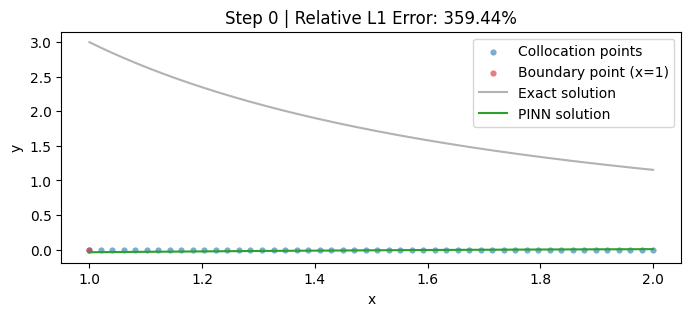

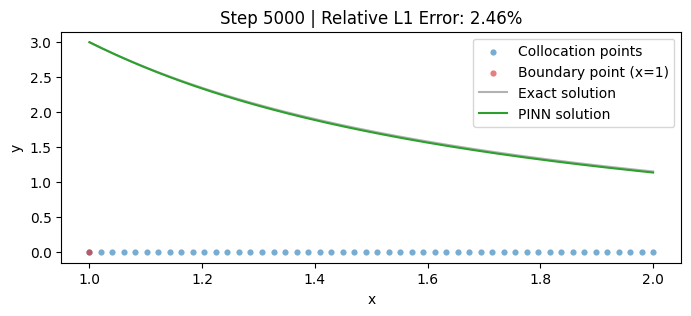

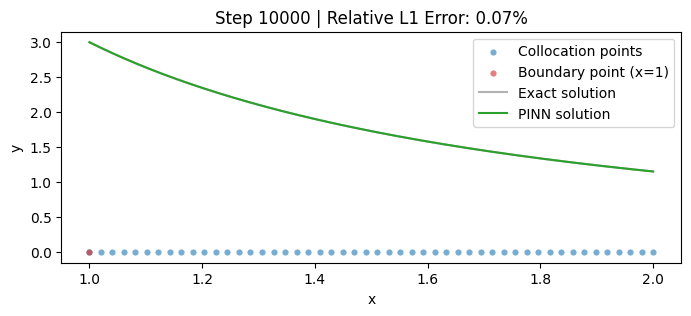

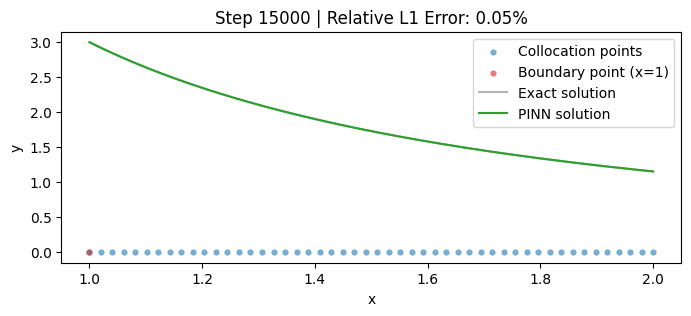

In [ ]:
@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):
    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network)
    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)
    return loss, opt_state, parameters

# Setup and Execution
x_boundary = jnp.array([1.0])
x_physics_batch = jnp.linspace(1, 2, 50).reshape(-1, 1)
x_test_batch = jnp.linspace(1, 2, 300).reshape(-1, 1)
y_exact_batch = jax.vmap(exact_solution)(x_test_batch)

network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

for i in range(15001):
    loss, opt_state, parameters = PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network)
    if i % 5000 == 0:
        y_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_test_batch)
        plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch)

## Task 2: Training a PINN to Invert for Underlying Parameters

#### The Objective
In this inverse problem, we assume the coefficient $\alpha$ of the first-order term is unknown:
$$x^2 \frac{d^2y}{dx^2} + \alpha x \frac{dy}{dx} + y = 0$$

Given the initial conditions $y(1)=3$ and $y'(1)=-4$, the exact solution is:
$$y(x) = \frac{3 - \ln(x)}{x}$$

Our goal is to use noisy observations generated from this solution to "discover" the true value of $\alpha = 3.0$, starting from an initial guess of $0.0$.

#### The JAX Approach
We treat $\alpha$ as a learnable parameter. In JAX's functional style, we pass $\alpha$ alongside the network `parameters` to our loss function and compute gradients for both using `jax.value_and_grad`.

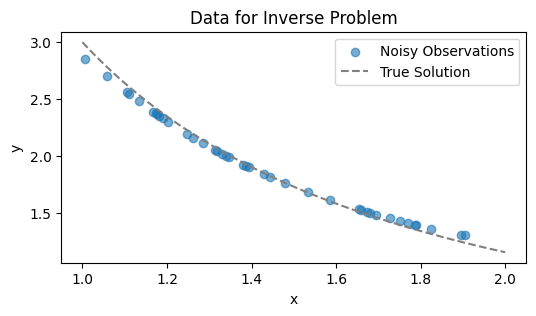

In [ ]:
# 1. Define the updated exact solution for data generation
def exact_solution(x):
    return (3.0 - jnp.log(x)) / x

# 2. Generate noisy observational data
key, subkey = jax.random.split(key)
# Randomly sample 40 points in the domain [1, 2]
x_obs = (1.0 + jax.random.uniform(subkey, (40, 1)))
# Generate true y values and add 5% Gaussian noise
y_obs = exact_solution(x_obs) + 0.05 * jax.random.normal(subkey, (40, 1))

# Visualize the data the PINN will learn from
plt.figure(figsize=(6, 3))
plt.scatter(x_obs, y_obs, label="Noisy Observations", color="tab:blue", alpha=0.6)
x_plot = jnp.linspace(1, 2, 100)
plt.plot(x_plot, exact_solution(x_plot), label="True Solution", color="grey", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Data for Inverse Problem")
plt.show()

Step 0 | Loss: 3.5636e+04 | Alpha Estimate: 0.0010
Step 1000 | Loss: 1.9478e+01 | Alpha Estimate: 1.1560
Step 2000 | Loss: 5.7836e+00 | Alpha Estimate: 1.9946
Step 3000 | Loss: 2.3982e+00 | Alpha Estimate: 2.4770
Step 4000 | Loss: 8.0829e-01 | Alpha Estimate: 2.8121
Step 5000 | Loss: 4.0577e-01 | Alpha Estimate: 2.9979
Step 6000 | Loss: 3.6481e-01 | Alpha Estimate: 3.0456
Step 7000 | Loss: 3.5558e-01 | Alpha Estimate: 3.0523
Step 8000 | Loss: 3.5082e-01 | Alpha Estimate: 3.0561
Step 9000 | Loss: 3.4892e-01 | Alpha Estimate: 3.0584
Step 10000 | Loss: 3.4759e-01 | Alpha Estimate: 3.0597
Step 11000 | Loss: 3.4700e-01 | Alpha Estimate: 3.0604
Step 12000 | Loss: 3.4933e-01 | Alpha Estimate: 3.0606
Step 13000 | Loss: 3.4640e-01 | Alpha Estimate: 3.0614
Step 14000 | Loss: 3.4623e-01 | Alpha Estimate: 3.0615
Step 15000 | Loss: 3.4617e-01 | Alpha Estimate: 3.0615


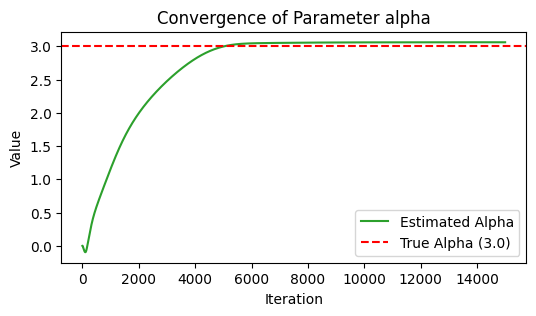

In [ ]:
# 1. Define Physics Loss with unknown alpha
def PINN_inverse_physics_loss(parameters, alpha, x, network):
    def y_fn(x_val):
        # Ensure network.forward handles single points for jax.grad
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    y = y_fn(x_val)
    dydx = jax.grad(y_fn)(x_val)
    d2ydx2 = jax.grad(jax.grad(y_fn))(x_val)

    # Physics residual: x^2*y'' + alpha*x*y' + y = 0
    residual = (x_val**2 * d2ydx2) + (alpha * x_val * dydx) + y
    return residual**2

# 2. Define Total Batch Loss (Physics + Data)
def PINN_inverse_loss_batch(params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    parameters, alpha = params_and_alpha

    # Vectorize physics loss over collocation points
    loss_physics = jnp.mean(jax.vmap(PINN_inverse_physics_loss, in_axes=(None, None, 0, None))(
        parameters, alpha, x_physics_batch, network))

    # Data loss: match observations
    y_pred_obs = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_obs)
    loss_data = jnp.mean((y_pred_obs - y_obs)**2)

    return loss_physics + 1e4 * loss_data

# 3. Define JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 6)) # Corrected: optimiser is at 1, network is at 6
def inverse_step(opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    """Updates PINN parameters and the unknown alpha using the optax optimiser"""

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=0)(
        params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    # apply parameter update
    updates, opt_state = optimiser.update(grads, opt_state, params_and_alpha)
    params_and_alpha = optax.apply_updates(params_and_alpha, updates)

    return loss, opt_state, params_and_alpha

# 4. Initialize and Run Training
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
alpha_init = jnp.array(0.0) # Initial guess
params_and_alpha = (parameters, alpha_init)

optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params_and_alpha)

alphas = []
for i in range(15001):
    loss, opt_state, params_and_alpha = inverse_step(
        opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    current_alpha = params_and_alpha[1]
    alphas.append(current_alpha)

    if i % 1000 == 0:
        print(f"Step {i} | Loss: {loss:.4e} | Alpha Estimate: {current_alpha:.4f}")

# Plot convergence
plt.figure(figsize=(6, 3))
plt.plot(alphas, label="Estimated Alpha", color="tab:green")
plt.axhline(y=3.0, color="red", linestyle="--", label="True Alpha (3.0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.title("Convergence of Parameter alpha")
plt.show()